In [1]:
# Customer Churn Prediction for a Telecom Company

# Phase 12 – Business Insights & Recommendations

# Objective

# Translate machine learning results into actionable business insights that can help the telecom company reduce customer churn, improve customer retention, and increase profitability.

# Tasks

# - Analyze churn trends
# - Identify high-risk customer groups
# - Estimate business impact
# - Visualize customer segments
# - Recommend retention strategies
# - Summarize executive insights

In [2]:
# Import Libraries

import os
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Create Output Folder

SAVE_PATH = "../images/10_Business_Insights"

os.makedirs(SAVE_PATH, exist_ok=True)

In [4]:
# Load Dataset

def _load_joblib_or_none(path):
    if os.path.exists(path):
        return joblib.load(path)
    print(f"Missing file: {path}")
    return None

excel_path = "../data/processed/feature_engineered_telco_customer_churn.xlsx"
if os.path.exists(excel_path):
    df = pd.read_excel(excel_path)
else:
    print(f"Missing file: {excel_path}")
    df = None

model = _load_joblib_or_none("../models/random_forest_tuned.pkl")

In [5]:
# Step 4: Predict Churn Probability

if df is None:
    print("Dataset missing; skipping prediction and downstream analysis.")
else:
    # Drop common target column names if present
    target_cols = ["Churn Label", "Churn", "Churn_Label", "ChurnLabel"]
    X = df.drop(columns=[c for c in target_cols if c in df.columns], errors='ignore')

    if X.shape[0] == 0:
        raise ValueError("No rows available in dataframe to predict.")

    # If the model records feature names, align and fill missing features with zeros
    if model is not None and hasattr(model, 'feature_names_in_'):
        expected = list(model.feature_names_in_)
        missing = [c for c in expected if c not in X.columns]
        if missing:
            print("Warning: adding missing features with zeros:", missing)
            for c in missing:
                X[c] = 0
        # Reorder columns to match training order
        X = X[expected]

    # Detect whether model is a Pipeline (so it can preprocess raw inputs)
    is_pipeline = hasattr(model, 'named_steps')

    # If not a pipeline, ensure X is numeric to avoid type conversion errors
    if (model is not None) and (not is_pipeline):
        from pandas.api.types import is_numeric_dtype
        non_numeric = [c for c in X.columns if not is_numeric_dtype(X[c])]
        if non_numeric:
            print("Model is not a Pipeline and input contains non-numeric columns; skipping prediction:", non_numeric)
            probability = [0.0] * len(X)
        else:
            # safe to call model
            try:
                if hasattr(model, 'predict_proba'):
                    probability = model.predict_proba(X)[:, 1]
                else:
                    probability = model.predict(X).astype(float)
            except Exception as e:
                print("Model prediction failed:", e)
                probability = [0.0] * len(X)
    else:
        # Model is a pipeline or None
        if model is None:
            print("No model available; creating placeholder churn probability of 0.0")
            probability = [0.0] * len(X)
        else:
            try:
                if hasattr(model, 'predict_proba'):
                    probability = model.predict_proba(X)[:, 1]
                else:
                    probability = model.predict(X).astype(float)
            except Exception as e:
                print("model.predict_proba/predict failed even with pipeline:", e)
                probability = [0.0] * len(X)

    # Attach results
    df["Churn Probability"] = probability

Model is not a Pipeline and input contains non-numeric columns; skipping prediction: ['Gender', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method', 'Tenure Group', 'Monthly Charge Group', 'Customer Value']


In [6]:
# Step 5: Customer Risk Segmentation

if df is None:
    print("Skipping risk segmentation: dataset missing")
else:
    def risk(score):
        if score >= 0.75:
            return "High"
        elif score >= 0.50:
            return "Medium"
        else:
            return "Low"

    df["Risk Category"] = df["Churn Probability"].apply(risk)

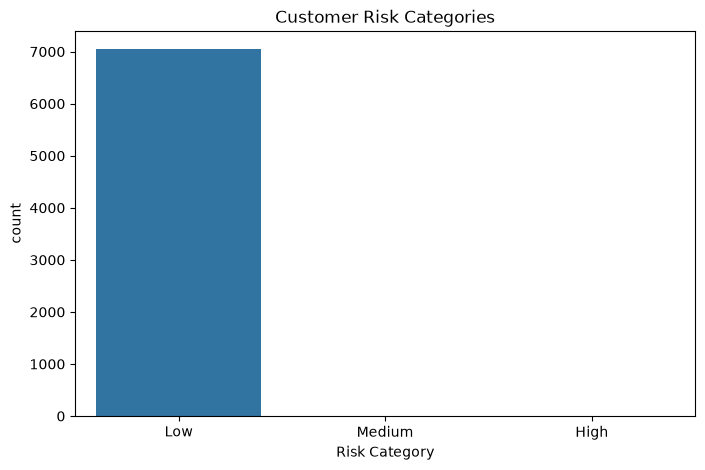

In [7]:
# Step 6: Risk Distribution

if df is None:
    print("Skipping risk distribution: dataset missing")
else:
    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x="Risk Category",
        order=["Low","Medium","High"],
    )

    plt.title("Customer Risk Categories")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "Risk_Distribution.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

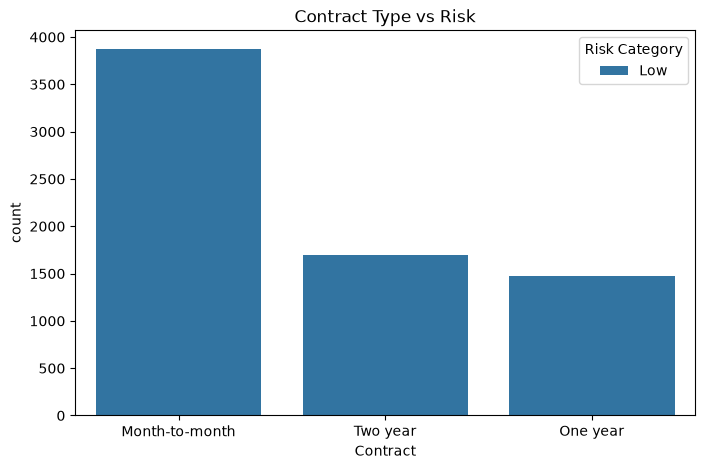

In [8]:
# Step 7: Churn by Contract

if df is None:
    print("Skipping contract vs risk plot: dataset missing")
else:
    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x="Contract",
        hue="Risk Category",
    )

    plt.title("Contract Type vs Risk")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "Contract_vs_Risk.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

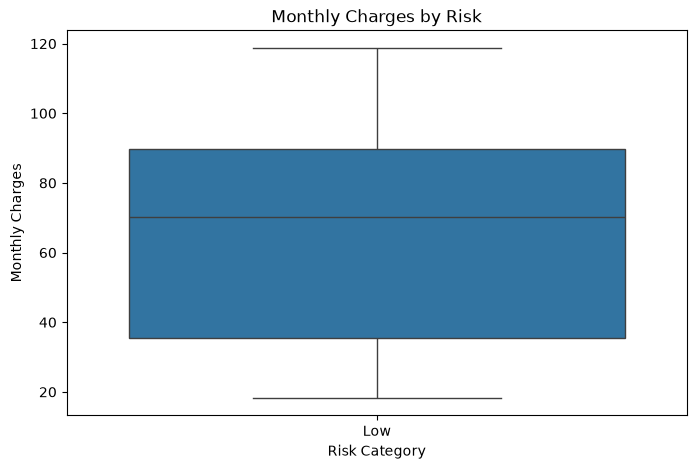

In [9]:
# Step 8: Monthly Charges by Risk

if df is None:
    print("Skipping monthly charges plot: dataset missing")
else:
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="Risk Category",
        y="Monthly Charges",
    )

    plt.title("Monthly Charges by Risk")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "MonthlyCharges_vs_Risk.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

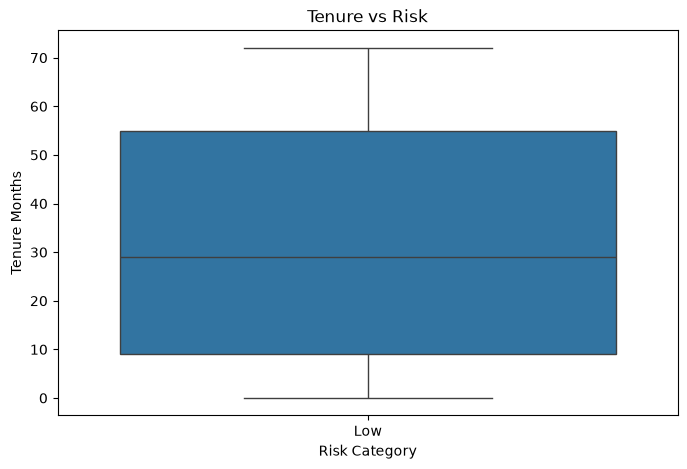

In [10]:
# Step 9: Tenure by Risk

if df is None:
    print("Skipping tenure plot: dataset missing")
else:
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="Risk Category",
        y="Tenure Months",
    )

    plt.title("Tenure vs Risk")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "Tenure_vs_Risk.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

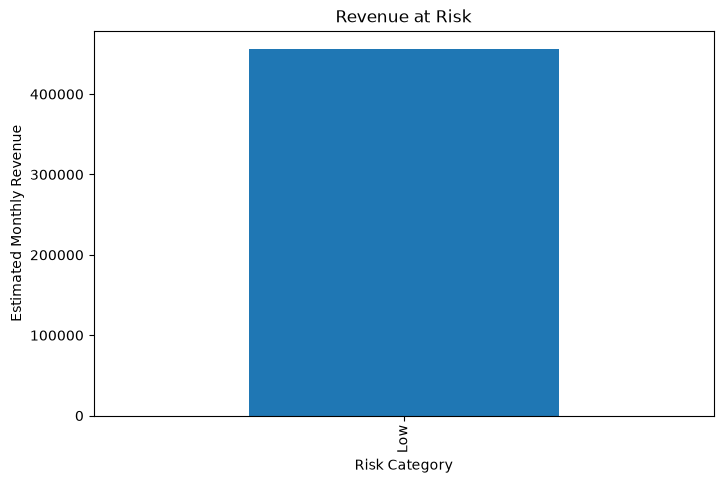

In [11]:
# Step 10: Estimated Revenue at Risk

if df is None:
    print("Skipping revenue at risk: dataset missing")
else:
    revenue = df.groupby("Risk Category")["Monthly Charges"].sum()

    plt.figure(figsize=(8,5))

    revenue.plot(kind="bar")

    plt.ylabel("Estimated Monthly Revenue")

    plt.title("Revenue at Risk")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "Revenue_at_Risk.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [12]:
# Step 11: Top High-Risk Customers

if df is None:
    print("Skipping top high-risk customers: dataset missing")
else:
    top_customers = df.sort_values(
        by="Churn Probability",
        ascending=False,
    ).head(20)

    top_customers

In [13]:
# Step 12: Save High-Risk Customers

if df is None:
    print("Skipping saving high-risk customers: dataset missing")
else:
    os.makedirs(os.path.join('..','reports'), exist_ok=True)
    top_customers.to_excel(
        "../reports/high_risk_customers.xlsx",
        index=False,
    )
    top_customers.to_csv(
        "../reports/high_risk_customers.csv",
        index=False,
    )

In [14]:
# Step 13: Business Summary Table

if df is None:
    print("Skipping business summary: dataset missing")
else:
    summary = pd.DataFrame({
        "Metric": [
            "Total Customers",
            "Predicted High Risk",
            "Average Monthly Charge",
            "Average Tenure",
        ],
        "Value": [
            len(df),
            len(df[df["Risk Category"] == "High"]),
            round(df["Monthly Charges"].mean(), 2),
            round(df["Tenure Months"].mean(), 2),
        ],
    })

    summary

In [15]:
# Step 14: Save Summary

if df is None:
    print("Skipping saving summary: dataset missing")
else:
    os.makedirs(os.path.join('..','reports'), exist_ok=True)
    summary.to_excel(
        "../reports/business_summary.xlsx",
        index=False,
    )

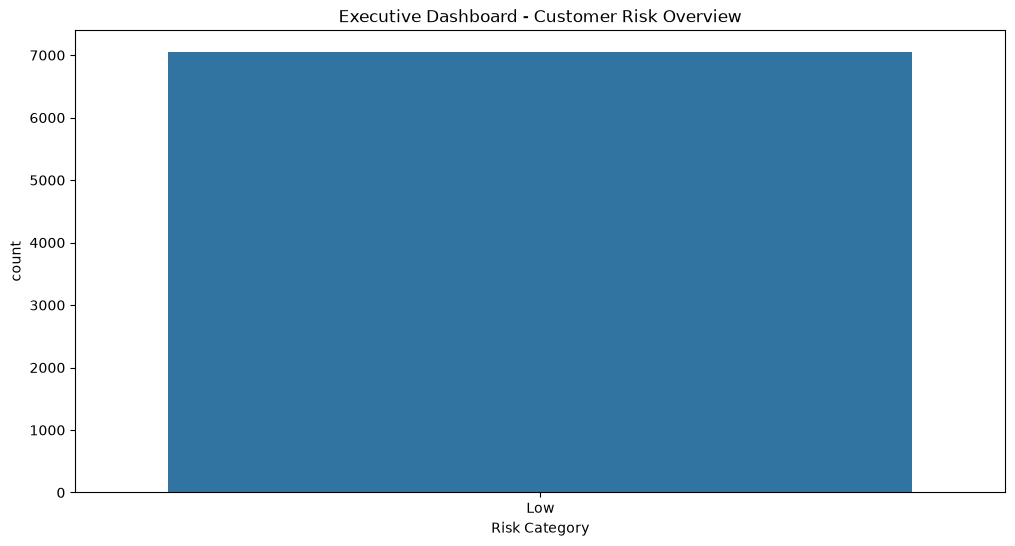

In [16]:
# Step 15: Executive Dashboard

if df is None:
    print("Skipping executive dashboard: dataset missing")
else:
    fig, ax = plt.subplots(figsize=(12,6))

    sns.countplot(
        data=df,
        x="Risk Category",
        ax=ax,
    )

    ax.set_title("Executive Dashboard - Customer Risk Overview")

    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "Executive_Dashboard.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [17]:
# 📌 Markdown Cell – Business Recommendations

# Business Recommendations

# 1. Focus on High-Risk Customers
# Customers with a churn probability greater than 75% should be prioritized for proactive retention campaigns.

# 2. Promote Long-Term Contracts
# Encourage month-to-month customers to migrate to annual or two-year contracts through discounts and loyalty programs.

# 3. Improve Customer Satisfaction
# Customers with lower satisfaction scores should receive targeted support and personalized engagement.

# 4. Review Pricing Strategy
# Customers with high monthly charges and short tenure show higher churn risk. Introduce flexible pricing or bundled offers.

# 5. Strengthen Loyalty Programs
# Reward long-term customers with exclusive benefits to increase retention and lifetime value.

# 6. Continuous Monitoring
# Deploy the trained model as a decision-support tool to identify at-risk customers regularly and trigger timely interventions.